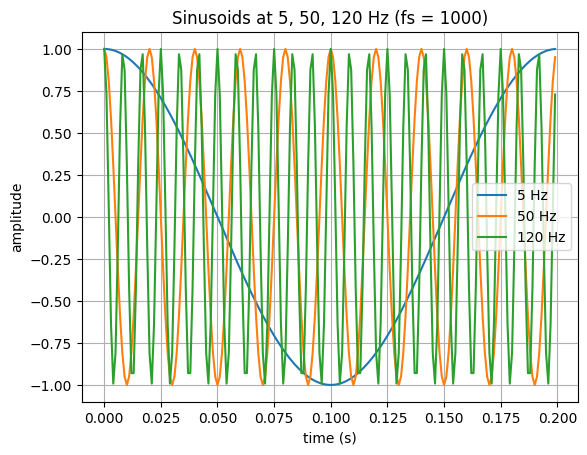

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fs = 1000.0          # sample rate, Hz
T = 1.0              # duration, seconds
N = int(fs * T)      # number of samples
n = np.arange(N)
t = n / fs           # time vector

# Three sinusoids at 5, 50, 120 Hz
for f0, label in [(5, "5 Hz"), (50, "50 Hz"), (120, "120 Hz")]:
    x = np.cos(2 * np.pi * f0 * t)
    plt.plot(t[:200], x[:200], label=label)  # plot first 200 samples
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.legend()
plt.title("Sinusoids at 5, 50, 120 Hz (fs = 1000)")
plt.grid(True)
plt.show()

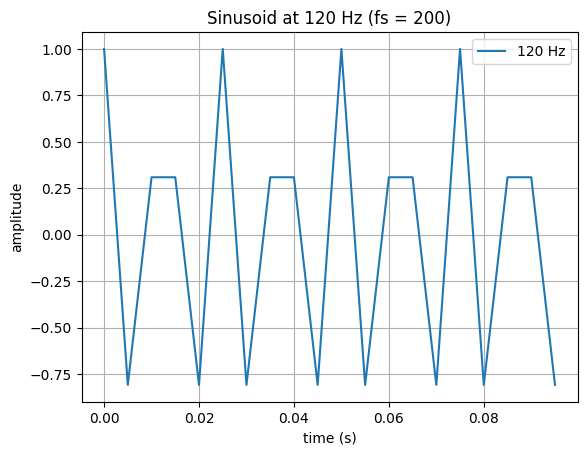

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fs = 200.0          # sample rate, Hz
T = 0.1              # duration, seconds
N = int(fs * T)      # number of samples
n = np.arange(N)
t = n / fs           # time vector

# One sinusoid with frequency 120 Hz
f0 = 120
label = "120 Hz"
x = np.cos(2 * np.pi * f0 * t)
plt.plot(t[:200], x[:200], label=label)  # plot first 200 samples
plt.xlabel("time (s)")
plt.ylabel("amplitude")
plt.legend()
plt.title("Sinusoid at 120 Hz (fs = 200)")
plt.grid(True)
plt.show()

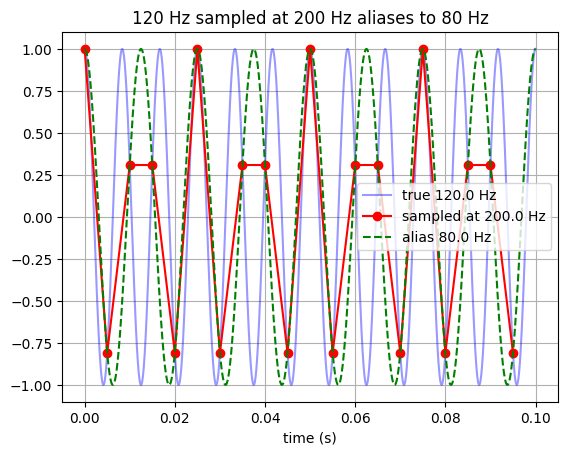

In [7]:
fs = 200.0
t_dense = np.linspace(0, 0.1, 2000)   # near-continuous, for the "truth" curve
t_samp  = np.arange(0, 0.1, 1/fs)     # actual sample times

f_true = 120.0
plt.plot(t_dense, np.cos(2*np.pi*f_true*t_dense), 'b-', alpha=0.4, label=f"true {f_true} Hz")
plt.plot(t_samp,  np.cos(2*np.pi*f_true*t_samp),  'ro-', label=f"sampled at {fs} Hz")

f_alias = abs(f_true - fs*round(f_true/fs))
plt.plot(t_dense, np.cos(2*np.pi*f_alias*t_dense), 'g--', label=f"alias {f_alias} Hz")
plt.xlabel("time (s)"); plt.legend(); plt.grid(True)
plt.title("120 Hz sampled at 200 Hz aliases to 80 Hz")
plt.show()

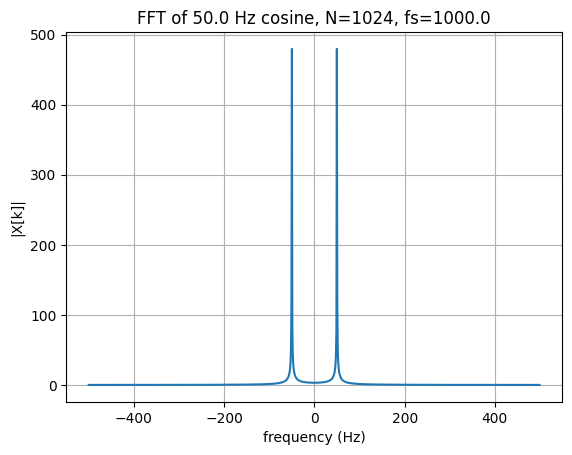

Bin spacing Δf = 0.9765625 Hz
Peak bins (top 4): [972  52 973  51]


In [10]:
from scipy.fft import fft, fftfreq, fftshift

fs = 1000.0
N = 1024
n = np.arange(N)
t = n / fs

f0 = 50.0
x = np.cos(2*np.pi*f0*t)

X = fft(x)
freqs = fftfreq(N, d=1/fs)        # frequency for each bin, in Hz

# Plot magnitude spectrum, shifted so 0 Hz is centered
plt.plot(fftshift(freqs), np.abs(fftshift(X)))
plt.xlabel("frequency (Hz)")
plt.ylabel("|X[k]|")
plt.title(f"FFT of {f0} Hz cosine, N={N}, fs={fs}")
plt.grid(True)
plt.show()

print("Bin spacing Δf =", fs/N, "Hz")
print("Peak bins (top 4):", np.argsort(np.abs(X))[-4:])

In [11]:
lhs = np.sum(np.abs(x)**2)
rhs = np.sum(np.abs(X)**2) / N
print(f"LHS = {lhs:.6f}, RHS = {rhs:.6f}, diff = {lhs - rhs:.2e}")

LHS = 512.904508, RHS = 512.904508, diff = 0.00e+00


In [17]:
x = np.cos(2*np.pi*50*np.arange(1024)/1000)
print(fft(x).shape)              # (1024,)
print(fft(x, n=16384).shape)     # (16384,)

(1024,)
(16384,)


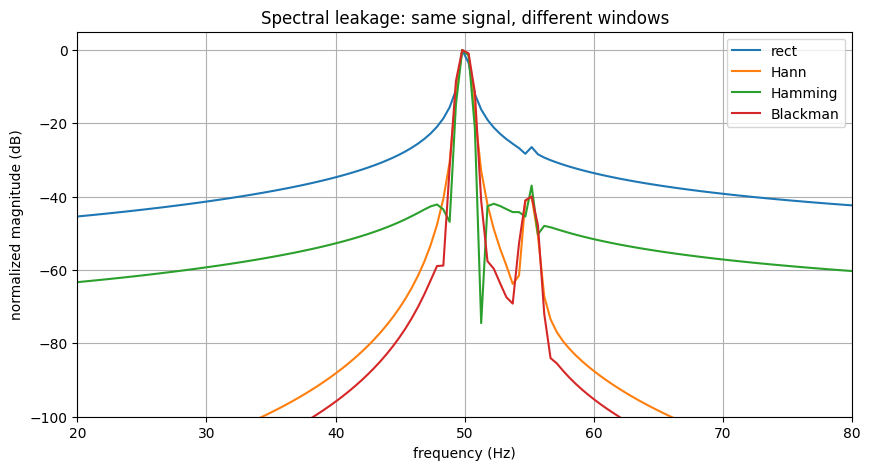

In [43]:
from scipy.signal.windows import hann, hamming, blackman

fs = 1000
N = 2048
n = np.arange(N)
t = n / fs
f0 = 50   # deliberately off-bin
f1 = 55
x = np.cos(2*np.pi*f0*t) + 0.01*np.cos(2*np.pi*f1*t)

windows = {
    "rect":     np.ones(N),
    "Hann":     hann(N),
    "Hamming":  hamming(N),
    "Blackman": blackman(N),
}

plt.figure(figsize=(10, 5))
for name, w in windows.items():
    Xw = fft(x * w)
    mag_db = 20*np.log10(np.abs(fftshift(Xw)) + 1e-12)
    plt.plot(fftshift(fftfreq(N, 1/fs)), mag_db - mag_db.max(), label=name)
plt.xlim(20, 80)
plt.ylim(-100, 5)
plt.xlabel("frequency (Hz)")
plt.ylabel("normalized magnitude (dB)")
plt.legend(); plt.grid(True)
plt.title("Spectral leakage: same signal, different windows")
plt.show()

In [13]:
print(type(windows))           # <class 'dict'>
print(windows.keys())          # dict_keys(['rect', 'Hann', 'Hamming', 'Blackman'])

w = windows["Hann"]
print(type(w))                 # <class 'numpy.ndarray'>
print(w.shape)                 # (1024,)
print(w.dtype)                 # float64
print(w[:5], "...", w[-5:])    # first and last few values
print("min:", w.min(), "max:", w.max())

<class 'dict'>
dict_keys(['rect', 'Hann', 'Hamming', 'Blackman'])
<class 'numpy.ndarray'>
(1024,)
float64
[0.00000000e+00 9.43076912e-06 3.77227207e-05 8.48747875e-05
 1.50885191e-04] ... [1.50885191e-04 8.48747875e-05 3.77227207e-05 9.43076912e-06
 0.00000000e+00]
min: 0.0 max: 0.9999976423021616


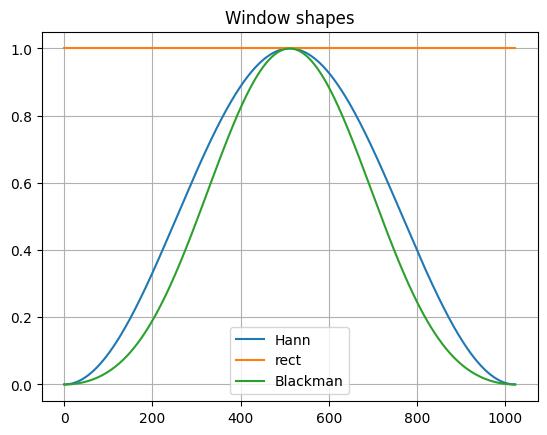

In [14]:
plt.plot(windows["Hann"], label="Hann")
plt.plot(windows["rect"], label="rect")
plt.plot(windows["Blackman"], label="Blackman")
plt.legend(); plt.grid(True); plt.title("Window shapes")
plt.show()

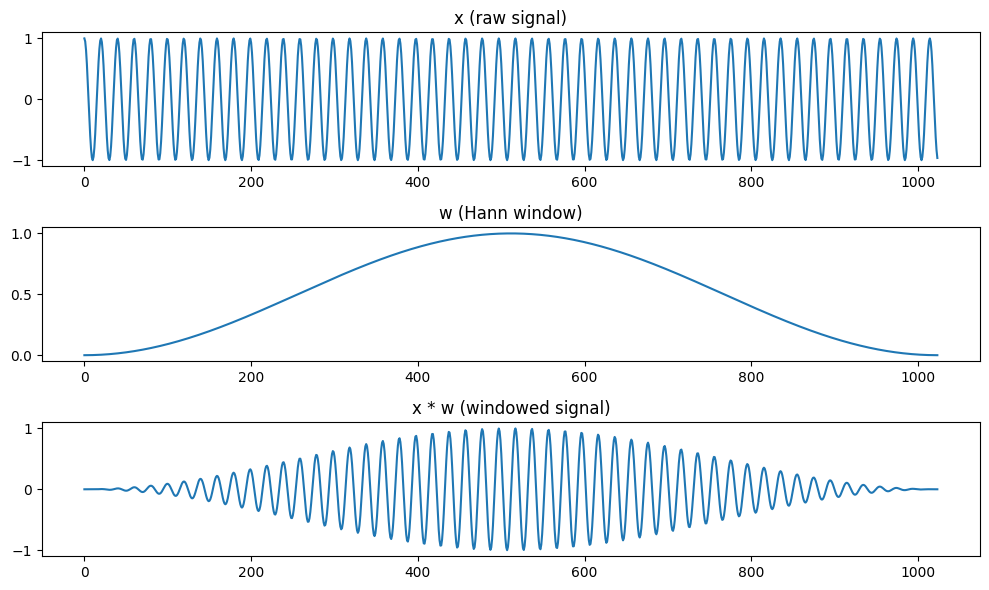

In [15]:
fs = 1000.0
N = 1024
n = np.arange(N)
t = n / fs
x = np.cos(2*np.pi*50.3*t)
w = hann(N)

fig, axes = plt.subplots(3, 1, figsize=(10, 6))
axes[0].plot(x);     axes[0].set_title("x (raw signal)")
axes[1].plot(w);     axes[1].set_title("w (Hann window)")
axes[2].plot(x * w); axes[2].set_title("x * w (windowed signal)")
plt.tight_layout(); plt.show()

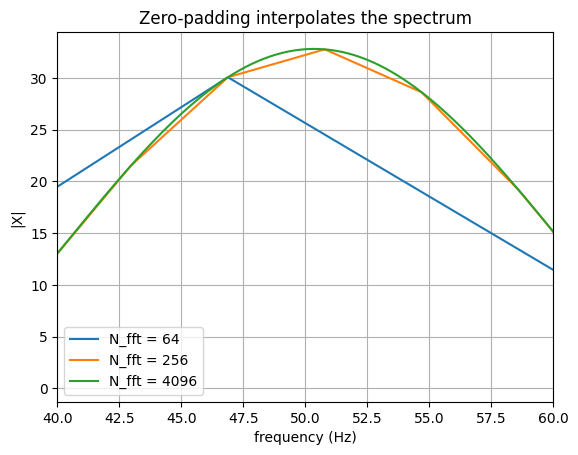

In [33]:
fs = 1000.0
N = 64                          # short record
n = np.arange(N)
t = n / fs
x = np.cos(2*np.pi*50.3*t)

for N_fft in [64, 256, 4096]:
    X = fft(x, n=N_fft)
    f = fftfreq(N_fft, 1/fs)
    plt.plot(fftshift(f), np.abs(fftshift(X)), label=f"N_fft = {N_fft}")
plt.xlim(40, 60)
plt.xlabel("frequency (Hz)"); plt.ylabel("|X|"); plt.legend(); plt.grid(True)
plt.title("Zero-padding interpolates the spectrum")
plt.show()

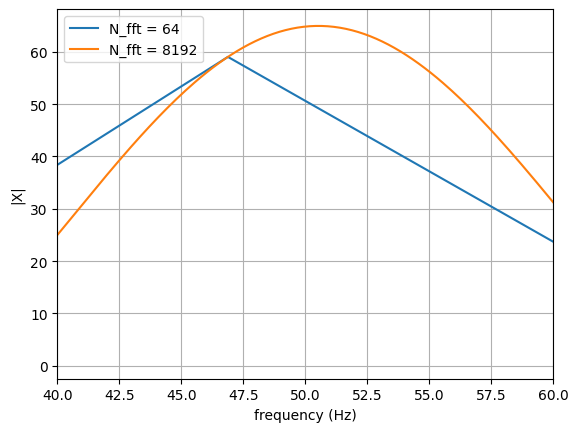

In [35]:
fs = 1000.0
N = 64                          # short record
n = np.arange(N)
t = n / fs
x = np.cos(2*np.pi*50*t) + np.cos(2*np.pi*51*t)

for N_fft in [64, 8192]:
    X = fft(x, n=N_fft)
    f = fftfreq(N_fft, 1/fs)
    plt.plot(fftshift(f), np.abs(fftshift(X)), label=f"N_fft = {N_fft}")
plt.xlim(40, 60)
plt.xlabel("frequency (Hz)"); plt.ylabel("|X|"); plt.legend(); plt.grid(True)
plt.show()

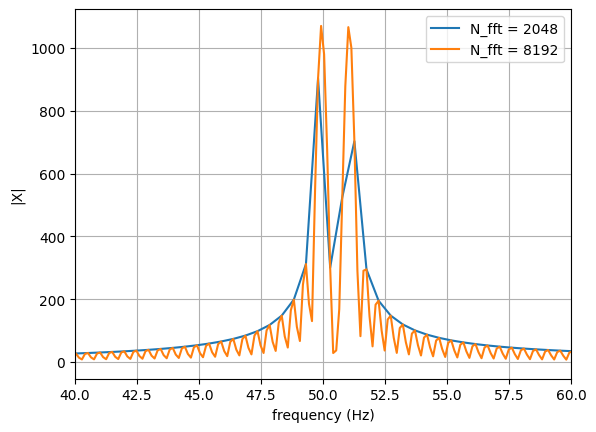

In [40]:
fs = 1000
N = 2048                          # short record
n = np.arange(N)
t = n / fs
x = np.cos(2*np.pi*50*t) + np.cos(2*np.pi*51*t)

for N_fft in [2048, 8192]:
    X = fft(x, n=N_fft)
    f = fftfreq(N_fft, 1/fs)
    plt.plot(fftshift(f), np.abs(fftshift(X)), label=f"N_fft = {N_fft}")
plt.xlim(40, 60)
plt.xlabel("frequency (Hz)"); plt.ylabel("|X|"); plt.legend(); plt.grid(True)
plt.show()

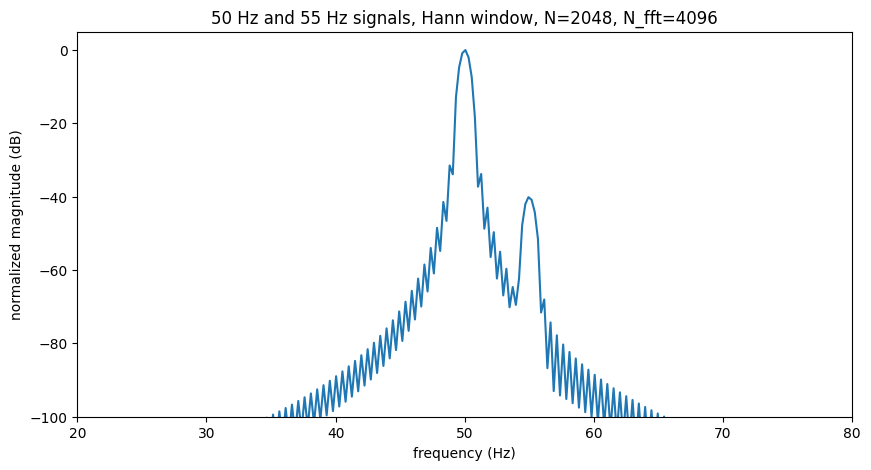

In [48]:
from scipy.signal.windows import hann, hamming, blackman

fs = 1000
N = 2048
n = np.arange(N)
t = n / fs
f0 = 50   # deliberately off-bin
f1 = 55
x = np.cos(2*np.pi*f0*t) + 0.01*np.cos(2*np.pi*f1*t)
w = hann(N)
N_fft = 4096
plt.figure(figsize=(10, 5))

Xw = fft(x * w, n=N_fft)

f = fftfreq(N_fft, 1/fs)
mag_db = 20*np.log10(np.abs(fftshift(Xw)) + 1e-12)
plt.plot(fftshift(f), mag_db - mag_db.max())
plt.xlim(20, 80)
plt.ylim(-100, 5)
plt.xlabel("frequency (Hz)")
plt.ylabel("normalized magnitude (dB)")
plt.title("50 Hz and 55 Hz signals, Hann window, N=2048, N_fft=4096")
plt.show()